# Actividad 7 - Redes Neuronales Artificiales

Equipo V6
* 2050547 Diana Ximena Torres Carranza
* 2177944 Juan Damian Camarena Arellano IMC
* 2177760 Ana Kaomi Garcia Rivera IMC
* 2177769 María Giselle Villarreal Ramírez IMC
* 2177915 José Carlos Luna Anaya

1. Cargar librerias

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


2. Cargar datos

In [ ]:
(train_data, train_labels), (test_data, test_labels) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


3. Preposicionamiento de datos

In [ ]:
# Redimensionar los datos a un arreglo 1D y normalizar
train_data = train_data.reshape(-1, 28*28) / 255.0
test_data = test_data.reshape(-1, 28*28) / 255.0

# Convertir etiquetas a codificación one-hot
train_labels = keras.utils.to_categorical(train_labels, num_classes=10)
test_labels = keras.utils.to_categorical(test_labels, num_classes=10)

print(f"Dimensiones de los datos de entrenamiento: {train_data.shape}")
print(f"Dimensiones de las etiquetas de entrenamiento: {train_labels.shape}")
print(f"Dimensiones de los datos de prueba: {test_data.shape}")
print(f"Dimensiones de las etiquetas de prueba: {test_labels.shape}")

Dimensiones de los datos de entrenamiento: (60000, 784)
Dimensiones de las etiquetas de entrenamiento: (60000, 10)
Dimensiones de los datos de prueba: (10000, 784)
Dimensiones de las etiquetas de prueba: (10000, 10)


4. Selección y entrenamiento de modelos

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)), # Capa oculta
    keras.layers.Dense(10, activation='softmax')                      # Capa de salida
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(train_data, train_labels, epochs=10, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9185 - loss: 0.2861 - val_accuracy: 0.9588 - val_loss: 0.1573
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9638 - loss: 0.1265 - val_accuracy: 0.9656 - val_loss: 0.1192
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9745 - loss: 0.0866 - val_accuracy: 0.9712 - val_loss: 0.0943
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9808 - loss: 0.0646 - val_accuracy: 0.9732 - val_loss: 0.0925
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9855 - loss: 0.0486 - val_accuracy: 0.9731 - val_loss: 0.0939
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9892 - loss: 0.0377 - val_accuracy: 0.9751 - val_loss: 0.0875
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9910 - loss: 0.0296 - val_accuracy: 0.9753 - val_loss: 0.0848
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9927 - loss: 0.0238 - 

5. Prueba del modelo

In [ ]:
loss, accuracy = model.evaluate(test_data, test_labels, verbose=0)
print(f"Exactitud de predicción del modelo en el conjunto de prueba: {accuracy*100:.2f}%")

Exactitud de predicción del modelo en el conjunto de prueba: 97.76%


6. Predicciones

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- 5 Predicciones de Prueba ---
Predicción para la imagen 1: 7, Valor Real: 7


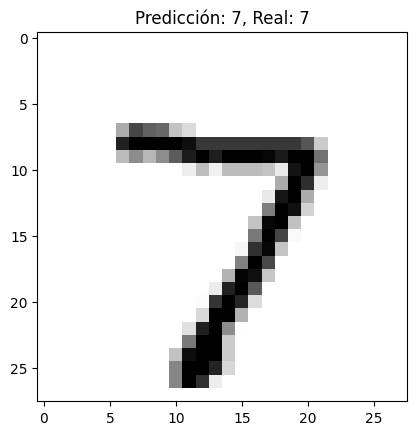

Predicción para la imagen 2: 2, Valor Real: 2


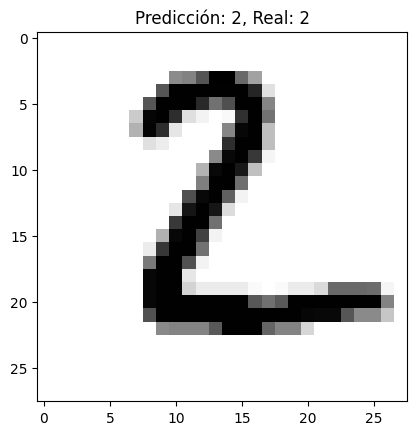

Predicción para la imagen 3: 1, Valor Real: 1


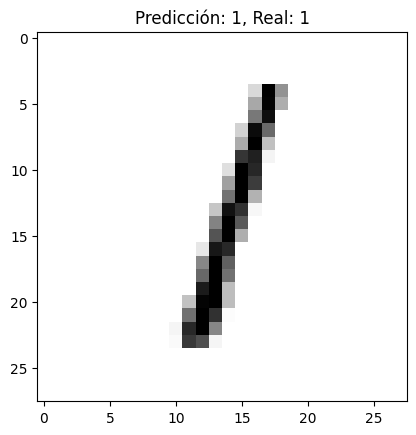

Predicción para la imagen 4: 0, Valor Real: 0


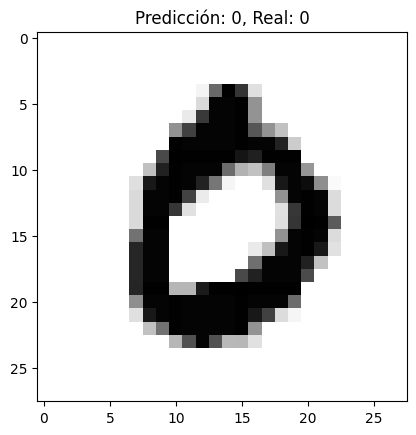

Predicción para la imagen 5: 4, Valor Real: 4


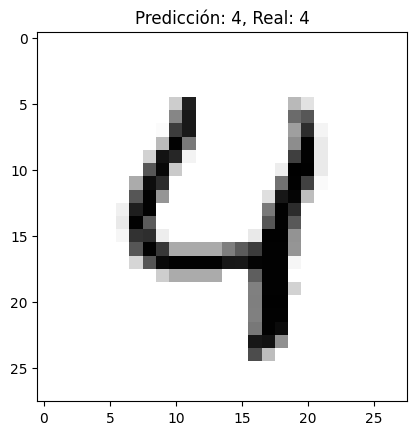

In [ ]:
predictions = model.predict(test_data)

print("\n--- 5 Predicciones de Prueba ---")
for i in range(5):
    predicted_label = np.argmax(predictions[i])
    true_label = np.argmax(test_labels[i])

    print(f"Predicción para la imagen {i+1}: {predicted_label}, Valor Real: {true_label}")

    # Mostrar la imagen
    plt.imshow(test_data[i].reshape(28, 28), cmap=plt.cm.binary)
    plt.title(f"Predicción: {predicted_label}, Real: {true_label}")
    plt.show()